# Notebook 1 — Data Preprocessing & Feature Engineering

## COS40007 Artificial Intelligence Engineering — Theme 5

**Goal:** Load raw 5G CSV files, clean, resample to a regular time grid,
engineer features, detect outliers, and export train/validation datasets
for downstream clustering and forecasting notebooks.

| Step | Task |
|------|------|
| 1 | Load & concatenate raw CSVs |
| 2 | EDA & strict cleaning |
| 3 | Regular time-series resampling (1 s per session) |
| 4 | Dtype optimisation & memory reduction |
| 5 | Post-cleaning EDA & correlation |
| 6 | Feature engineering (temporal · network) |
| 7 | Stationarity check (ADF test) |
| 8 | Outlier detection & capping |
| 9 | Lag / rolling features (per truck + square_id) |
| 10 | Feature selection & reduction |
| 11 | Geospatial features |
| 12 | Train / validation temporal split |
| 13 | Export cleaned & scaled CSVs |

**No models are trained in this notebook.**

---
## Step 0 — Environment & Project Paths

In [1]:
import glob
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="muted")

BASE_DIR   = Path(".")
DATA_DIR   = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw CSV directory : {DATA_DIR.resolve()}")

Raw CSV directory : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\data


---
## Step 1 — Data Loading & EDA (40 % of grade)

In [2]:
# ── 1a. Concatenate all raw CSV files ──────────────────────
csv_files = sorted(glob.glob(str(DATA_DIR / "*.csv")))
# Exclude any previously generated output files
csv_files = [f for f in csv_files
             if Path(f).stem not in ("cleaned_5g_data", "map_data")]
print(f"Found {len(csv_files)} raw CSV files in {DATA_DIR.resolve()}")

frames = []
for fp in csv_files:
    try:
        tmp = pd.read_csv(fp, low_memory=False)
        tmp["source_file"] = Path(fp).stem
        frames.append(tmp)
    except Exception as exc:
        print(f"  ⚠ skipped {fp}: {exc}")

df = pd.concat(frames, ignore_index=True)
print(f"Combined shape: {df.shape}")
print(f"Columns ({len(df.columns)}):\n{list(df.columns)}")
df.head(3)

Found 136 raw CSV files in D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\data
Combined shape: (3042495, 33)
Columns (33):
['time', 'Day', 'Year', 'Month', 'Date', 'hour', 'min', 'sec', 'timezone', 'latitude', 'longitude', 'speed', 'truck', 'svr1', 'svr2', 'svr3', 'svr4', 'Role', 'Transfer size', 'Transfer unit', 'Bitrate', 'bitrate_unit', 'Retransmissions', 'CWnd', 'cwnd_unit', 'Role-RX', 'Transfer size-RX', 'Transfer unit-RX', 'Bitrate-RX', 'bitrate_unit-RX', 'send_data', 'square_id', 'source_file']


,time,Day,Year,Month,Date,hour,min,sec,timezone,latitude,longitude,speed,truck,svr1,svr2,svr3,svr4,Role,Transfer size,Transfer unit,Bitrate,bitrate_unit,Retransmissions,CWnd,cwnd_unit,Role-RX,Transfer size-RX,Transfer unit-RX,Bitrate-RX,bitrate_unit-RX,send_data,square_id,source_file
0,1656877022,Mon,2022.0,7.0,4.0,5.0,37.0,2.0,AEST,99.0,999.0,-1.0,garbo01,1000.0,1000.0,1000.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-04-garbo01-combined-kml
1,1656877022,Mon,2022.0,7.0,4.0,5.0,37.0,2.0,AEST,99.0,999.0,-1.0,garbo01,1000.0,1000.0,1000.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-04-garbo01-combined-kml
2,1656877022,Mon,2022.0,7.0,4.0,5.0,37.0,2.0,AEST,99.0,999.0,-1.0,garbo01,1000.0,1000.0,1000.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-04-garbo01-combined-kml


In [3]:
# ── 1b. Quick EDA before cleaning ──────────────────────────
print("── dtypes ──")
print(df.dtypes.value_counts())
print(f"\n── Missing values (top 15) ──")
print(df.isnull().sum().sort_values(ascending=False).head(15))
print(f"\n── Descriptive stats ──")
df.describe()

── dtypes ──
float64    18
object     14
int64       1
Name: count, dtype: int64

── Missing values (top 15) ──
svr4         593977
svr3         593975
svr2         593975
svr1         593975
square_id    560818
truck        343812
speed        343810
latitude     343809
longitude    343809
timezone     343807
hour         343807
sec          343807
min          343807
Date         343806
Day          343806
dtype: int64

── Descriptive stats ──


,time,Year,Month,Date,hour,min,sec,latitude,longitude,speed,svr1,svr2,svr3,svr4,Transfer size,Bitrate,Transfer size-RX,Bitrate-RX,send_data
count,3.042495e+06,2698689.0,2698689.0,2.698689e+06,2.698688e+06,2.698688e+06,2.698688e+06,2.698686e+06,2.698686e+06,2.698685e+06,2.448520e+06,2.448520e+06,2.448520e+06,2.448518e+06,2.713533e+06,2.713533e+06,2.713460e+06,2.713460e+06,2.788962e+06
mean,1.657619e+09,2022.0,7.0,1.218967e+01,8.817216e+00,2.961934e+01,2.948782e+01,-2.737269e+01,2.096419e+02,1.374754e+01,2.839526e+02,2.838819e+02,3.030290e+02,2.998318e+02,1.068046e+00,8.966052e+00,2.014400e+00,1.689644e+01,2.996928e-01
std,3.814960e+06,0.0,0.0,6.021038e+00,2.308625e+00,1.745151e+01,1.731720e+01,3.622062e+01,2.262437e+02,2.293579e+01,3.725512e+02,3.725267e+02,3.651250e+02,3.667629e+02,1.140621e+00,8.254232e+00,1.992016e+00,1.661119e+01,9.339412e-01
min,-2.147484e+09,2022.0,7.0,4.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,-3.782882e+01,1.447181e+02,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.657080e+09,2022.0,7.0,6.000000e+00,7.000000e+00,1.400000e+01,1.400000e+01,-3.778170e+01,1.447747e+02,2.852080e-01,3.350000e+01,3.340000e+01,3.810000e+01,5.200000e+01,0.000000e+00,0.000000e+00,7.460938e-01,6.260000e+00,0.000000e+00
50%,1.657592e+09,2022.0,7.0,1.200000e+01,9.000000e+00,3.000000e+01,2.900000e+01,-3.775104e+01,1.448013e+02,2.744664e+00,6.320000e+01,6.290000e+01,1.430000e+02,8.180000e+01,1.250000e+00,1.050000e+01,1.470000e+00,1.230000e+01,3.130817e-02
75%,1.658123e+09,2022.0,7.0,1.800000e+01,1.100000e+01,4.500000e+01,4.400000e+01,-3.771678e+01,1.448267e+02,1.592164e+01,4.120000e+02,4.120000e+02,4.270000e+02,4.340000e+02,1.250000e+00,1.050000e+01,2.900000e+00,2.430000e+01,2.629497e-01
max,1.658479e+09,2022.0,7.0,2.200000e+01,1.600000e+01,5.900000e+01,5.900000e+01,9.900000e+01,9.990000e+02,1.086105e+02,2.493000e+03,2.496000e+03,2.495000e+03,2.523000e+03,9.330000e+02,9.440000e+01,3.140000e+02,3.370000e+02,1.861712e+01


In [4]:
# ── 1c. Apply strict cleaning rules ───────────────────────
rows_before = len(df)

# 1. Construct Timestamp from Unix epoch column "time"
df["Timestamp"] = pd.to_datetime(df["time"], unit="s", errors="coerce")
df.dropna(subset=["Timestamp"], inplace=True)

# 2. Compute average latency from svr1-svr4 (exclude 1000 = timeout sentinel)
svr_cols = ["svr1", "svr2", "svr3", "svr4"]
svr_valid = df[svr_cols].replace(1000.0, np.nan)
df["Avg-RTT"] = svr_valid.mean(axis=1)

# 3. Remove rows with no valid GPS (sentinel values: lat=99, lon=999 etc.)
gps_sentinel = df["latitude"].abs().gt(90) | df["longitude"].abs().gt(180)
df = df[~gps_sentinel].copy()

# 4. Melbourne / Brimbank bounding box (generous buffer)
LAT_MIN, LAT_MAX = -37.85, -37.70
LON_MIN, LON_MAX = 144.75, 144.90
geo_mask = (
    df["latitude"].between(LAT_MIN, LAT_MAX)
    & df["longitude"].between(LON_MIN, LON_MAX)
)
df = df[geo_mask].copy()

# 5. Drop rows where all svr values were timeout (Avg-RTT is NaN)
df.dropna(subset=["Avg-RTT"], inplace=True)

# 6. Remove negative bitrates
for col in ["Bitrate", "Bitrate-RX"]:
    if col in df.columns:
        df = df[df[col].notna() & (df[col] >= 0)].copy()

# 7. Drop rows with missing truck or square_id (required for grouping)
df.dropna(subset=["truck", "square_id"], inplace=True)

rows_after = len(df)
print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows after cleaning  : {rows_after:,}")
print(f"Rows removed         : {rows_before - rows_after:,} "
      f"({(rows_before - rows_after) / rows_before * 100:.1f} %)")
print(f"Unique trucks        : {df['truck'].nunique()}")
print(f"Unique square_ids    : {df['square_id'].nunique()}")

Rows before cleaning : 3,042,495
Rows after cleaning  : 1,560,562
Rows removed         : 1,481,933 (48.7 %)
Unique trucks        : 11
Unique square_ids    : 227


### Step 1f — Regular Time-Series Resampling

The raw measurements are at irregular ~1 s intervals.
Resampling each (truck, square_id) session to exactly 1 s ensures
lag/rolling features see evenly-spaced data. Gaps larger than 60 s
are treated as session boundaries and are **not** interpolated across.

In [5]:
# ── 1f. Regular time-series resampling (1 s per session) ──
# Each (truck, square_id) group is split into contiguous measurement
# sessions (gap > MAX_GAP_S starts a new session) to avoid creating
# rows across multi-hour idle periods.
MAX_GAP_S = 60

df.sort_values(["truck", "square_id", "Timestamp"], inplace=True)

# Identify contiguous sessions
df["_gap"] = df.groupby(["truck", "square_id"])["Timestamp"].diff()
df["_session"] = (
    df.groupby(["truck", "square_id"])["_gap"]
      .transform(lambda s: (s > pd.Timedelta(seconds=MAX_GAP_S))
                            .fillna(True).cumsum())
)
df.drop(columns=["_gap"], inplace=True)

# Separate columns for interpolation vs forward-fill
_no_interp = {"square_id", "ue_id", "_session"}
_num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
             if c not in _no_interp]
_fill_cols = [c for c in df.columns
              if c not in _num_cols and c != "Timestamp"]

def _resample_session(g: pd.DataFrame) -> pd.DataFrame:
    g = g.set_index("Timestamp").resample("1s").first()
    fills = [c for c in _fill_cols if c in g.columns]
    nums  = [c for c in _num_cols if c in g.columns]
    if fills:
        g[fills] = g[fills].ffill()
    if nums:
        g[nums] = g[nums].interpolate(method="linear", limit=MAX_GAP_S)
    return g

rows_pre = len(df)
df = (
    df.groupby(["truck", "square_id", "_session"], group_keys=False)
      .apply(_resample_session)
      .reset_index()
)
df.drop(columns=["_session"], inplace=True, errors="ignore")

# Drop rows still fully NaN (edge artefacts from resampling)
key_cols = [c for c in ["Bitrate-RX", "Avg-RTT"] if c in df.columns]
if key_cols:
    df.dropna(subset=key_cols, how="all", inplace=True)

print(f"Rows before resampling: {rows_pre:,}")
print(f"Rows after  resampling: {len(df):,}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_19848\3323222889.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_resample_session)


Rows before resampling: 1,560,562
Rows after  resampling: 2,041,013


### Step 1g — Dtype Optimisation & Memory Reduction

In [6]:
# ── 1g. Dtype optimisation — reduce memory footprint ──────

def _optimise_dtypes(frame: pd.DataFrame) -> pd.DataFrame:
    """Down-cast numeric columns to smallest viable dtype."""
    for col in frame.select_dtypes(include=["float64"]).columns:
        frame[col] = pd.to_numeric(frame[col], downcast="float")
    for col in frame.select_dtypes(include=["int64"]).columns:
        frame[col] = pd.to_numeric(frame[col], downcast="integer")
    return frame

mem_before = df.memory_usage(deep=True).sum() / 1e6
df = _optimise_dtypes(df)
mem_after = df.memory_usage(deep=True).sum() / 1e6
print(f"Memory: {mem_before:.1f} MB → {mem_after:.1f} MB  "
      f"(saved {mem_before - mem_after:.1f} MB, "
      f"{(1 - mem_after / mem_before) * 100:.0f} %)")

Memory: 1895.3 MB → 1740.2 MB  (saved 155.1 MB, 8 %)


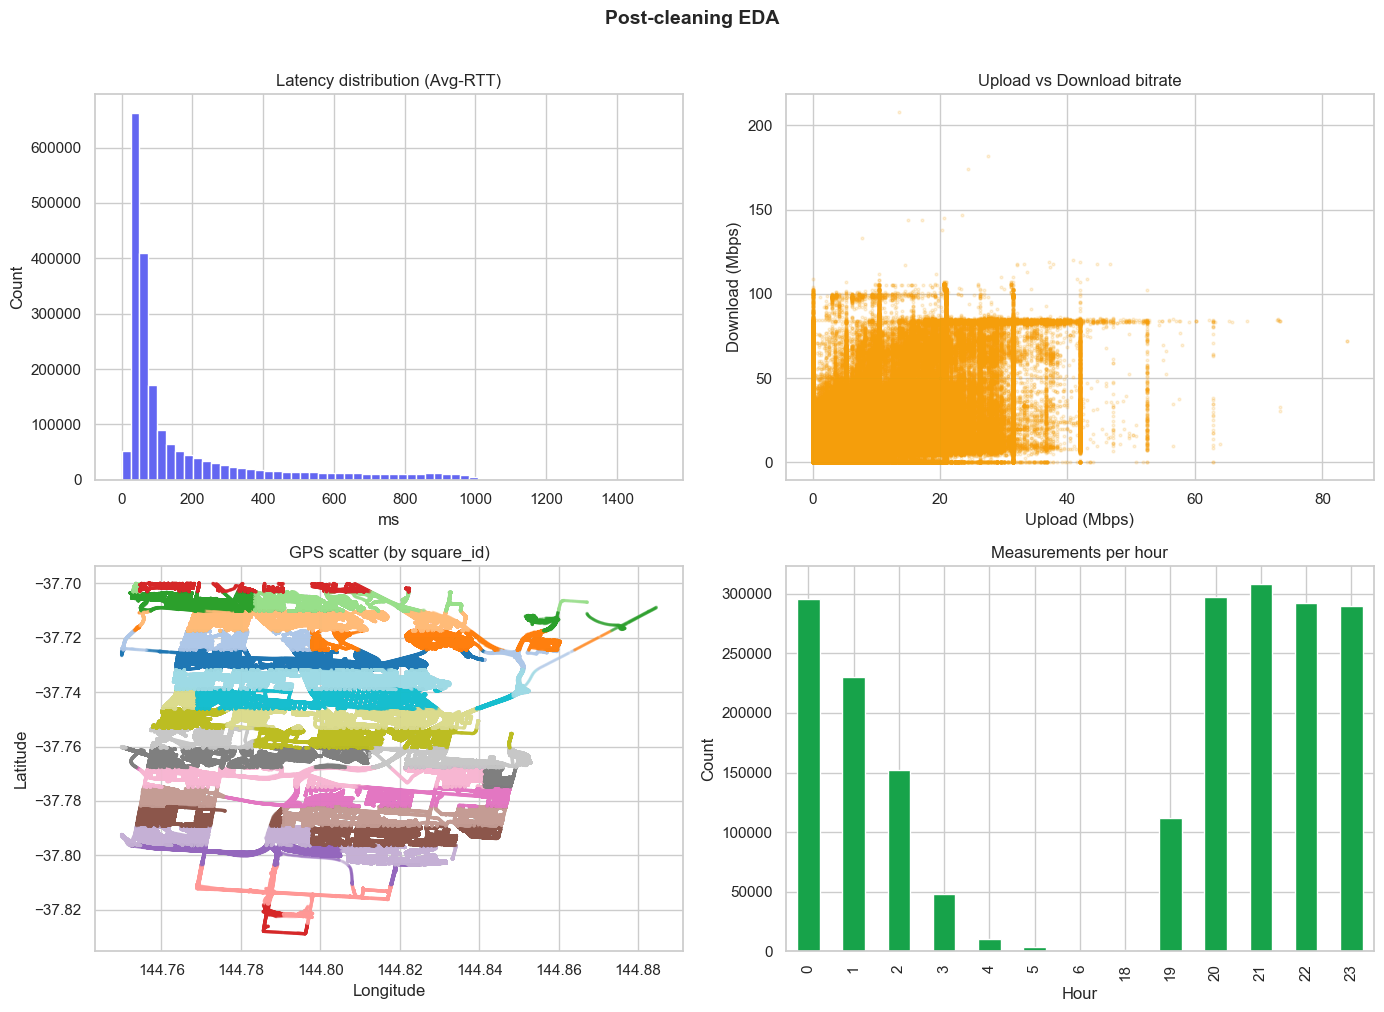

In [7]:
# ── 1d. Post-cleaning EDA visualisation ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["Avg-RTT"].dropna(), bins=60, color="#6366f1", edgecolor="white")
axes[0, 0].set(title="Latency distribution (Avg-RTT)", xlabel="ms", ylabel="Count")

valid_mask = df["Bitrate"].notna() & df["Bitrate-RX"].notna()
axes[0, 1].scatter(
    df.loc[valid_mask, "Bitrate"].values,
    df.loc[valid_mask, "Bitrate-RX"].values,
    alpha=0.15, s=4, color="#f59e0b",
)
axes[0, 1].set(title="Upload vs Download bitrate", xlabel="Upload (Mbps)", ylabel="Download (Mbps)")

scatter = axes[1, 0].scatter(
    df["longitude"], df["latitude"],
    c=df["square_id"].astype("category").cat.codes,
    cmap="tab20", s=2, alpha=0.3,
)
axes[1, 0].set(title="GPS scatter (by square_id)", xlabel="Longitude", ylabel="Latitude")

df["_hour"] = df["Timestamp"].dt.hour
df["_hour"].value_counts().sort_index().plot.bar(ax=axes[1, 1], color="#17a34a")
axes[1, 1].set(title="Measurements per hour", xlabel="Hour", ylabel="Count")
df.drop(columns=["_hour"], inplace=True)

fig.suptitle("Post-cleaning EDA", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

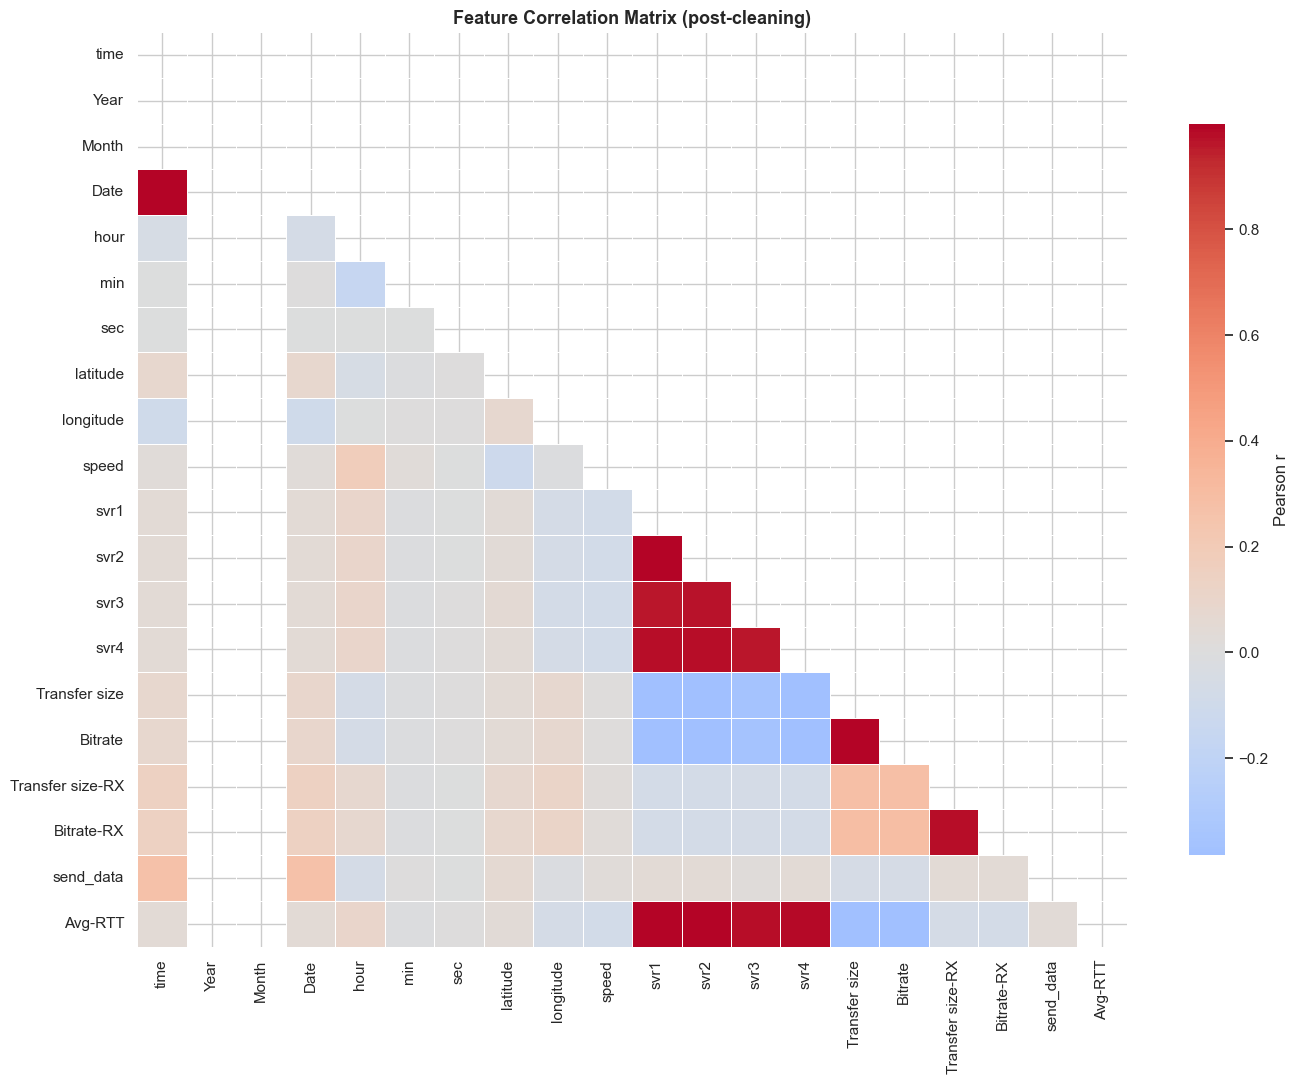

Top 10 strongest correlations:
 Feature A        Feature B        r    abs_r
   Bitrate    Transfer size 0.999999 0.999999
      Date             time 0.999891 0.999891
   Avg-RTT             svr2 0.992061 0.992061
      svr2             svr1 0.991801 0.991801
   Avg-RTT             svr1 0.991732 0.991732
   Avg-RTT             svr4 0.986038 0.986038
      svr4             svr2 0.983771 0.983771
Bitrate-RX Transfer size-RX 0.982564 0.982564
      svr4             svr1 0.981047 0.981047
   Avg-RTT             svr3 0.979670 0.979670


In [8]:
# ── 1e. Correlation heatmap ───────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
drop_cols = [c for c in ["square_id", "ue_id"] if c in numeric_cols]
corr_cols = [c for c in numeric_cols if c not in drop_cols]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title("Feature Correlation Matrix (post-cleaning)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

upper = corr_matrix.where(mask == False)
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "r"})
)
pairs["abs_r"] = pairs["r"].abs()
pairs = pairs[pairs["abs_r"] < 1.0].sort_values("abs_r", ascending=False)
print("Top 10 strongest correlations:")
print(pairs.head(10).to_string(index=False))

---
## Step 2 — Advanced Feature Engineering

Feature families (all grouped by **truck + square_id**):
1. **Temporal** — cyclical sin/cos for hour & day-of-week, work-hour flag, weekend flag.
2. **Network** — throughput/latency in Mbps/ms, retransmission rate, CWND, congestion indicator, jitter, interactions & ratios.
3. **Stationarity** — ADF test per truck; differenced targets created.
4. **Outlier capping** — percentile-based (1st / 99th) with flag columns.
5. **Row-level lag/rolling** — per-truck + square_id autoregressive features (look-ahead bias annotated).
6. **Feature selection** — drop highly-correlated (>0.95) features; export scaled version.
7. **Geospatial** — distance to Melbourne CBD.

In [9]:
# ── 2a. Temporal feature engineering ───────────────────────
df["hour"]    = df["Timestamp"].dt.hour
df["dow"]     = df["Timestamp"].dt.dayofweek   # 0=Mon … 6=Sun
df["is_weekend"] = (df["dow"] >= 5).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"]  = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"]  = np.cos(2 * np.pi * df["dow"] / 7)

df["is_work_hour"] = ((df["dow"] < 5) & df["hour"].between(8, 17)).astype(int)

print("Temporal features added:")
print("  hour, dow, is_weekend, hour_sin, hour_cos, dow_sin, dow_cos, is_work_hour")
print(f"  Work-hour rows: {df['is_work_hour'].sum():,} / {len(df):,}")

Temporal features added:
  hour, dow, is_weekend, hour_sin, hour_cos, dow_sin, dow_cos, is_work_hour
  Work-hour rows: 0 / 2,041,013


In [10]:
# ── 2b. Network / Telecom feature engineering ──────────────
df["upload_mbps"]   = pd.to_numeric(df["Bitrate"], errors="coerce")
df["download_mbps"] = pd.to_numeric(df["Bitrate-RX"], errors="coerce")
df["avg_latency"]   = df["Avg-RTT"]

# Retransmission rate
if "Retransmissions" in df.columns and "Transfer size" in df.columns:
    retrans = pd.to_numeric(df["Retransmissions"], errors="coerce").fillna(0)
    xfer    = pd.to_numeric(df["Transfer size"], errors="coerce").replace(0, np.nan)
    df["retransmission_rate"] = (retrans / xfer).fillna(0).clip(0, 1)
elif "Retransmissions" in df.columns:
    retrans = pd.to_numeric(df["Retransmissions"], errors="coerce").fillna(0)
    max_retrans = retrans.quantile(0.99)
    df["retransmission_rate"] = (retrans / max_retrans).clip(0, 1) if max_retrans > 0 else 0.0
else:
    df["retransmission_rate"] = 0.0

# CWND features
if "CWnd" in df.columns:
    df["cwnd"] = pd.to_numeric(df["CWnd"], errors="coerce").fillna(0)
    df["cwnd_squared"] = df["cwnd"] ** 2
else:
    df["cwnd"] = 0.0
    df["cwnd_squared"] = 0.0

# Server-level latency features
svr_cols = [c for c in df.columns if c.startswith("svr") and c[3:].isdigit()]
if len(svr_cols) >= 2:
    svr_valid = df[svr_cols].replace(1000.0, np.nan)
    df["latency_spread"] = svr_valid.max(axis=1) - svr_valid.min(axis=1)
    df["latency_std"]    = svr_valid.std(axis=1)
    df["latency_spread"].fillna(0, inplace=True)
    df["latency_std"].fillna(0, inplace=True)
else:
    df["latency_spread"] = 0.0
    df["latency_std"]    = 0.0

# Congestion indicator
lat_75 = df["avg_latency"].quantile(0.75)
dl_25  = df["download_mbps"].quantile(0.25)
df["congestion_indicator"] = (
    (df["avg_latency"] > lat_75) & (df["download_mbps"] < dl_25)
).astype(int)

# Interaction features
df["latency_x_retrans"]  = df["avg_latency"] * df["retransmission_rate"]
df["cwnd_x_speed"]       = df["cwnd"] * df["download_mbps"]
df["download_x_latency"] = df["download_mbps"] * df["avg_latency"]

# Ratio features
df["cwnd_to_latency"]    = df["cwnd"] / df["avg_latency"].replace(0, np.nan)
df["download_to_upload"] = df["download_mbps"] / df["upload_mbps"].replace(0, np.nan)
df["cwnd_to_latency"].fillna(0, inplace=True)
df["download_to_upload"].fillna(0, inplace=True)

# Jitter proxy (grouped by truck + square_id to avoid mixing trucks)
df.sort_values(["truck", "square_id", "Timestamp"], inplace=True)
df["jitter"] = (
    df.groupby(["truck", "square_id"])["avg_latency"]
      .diff().abs().fillna(0)
)

print(f"Total features after engineering: {len(df.columns)}")
print(f"  retransmission_rate mean: {df['retransmission_rate'].mean():.4f}")
print(f"  congestion_indicator:     {df['congestion_indicator'].sum():,} rows")

Total features after engineering: 57
  retransmission_rate mean: 0.2097
  congestion_indicator:     126,230 rows


### Step 2c — Stationarity Check (ADF Test)

Run the Augmented Dickey-Fuller test per truck on `download_mbps` and
`avg_latency`. Non-stationary series are differenced for models that
require stationarity (e.g., ARIMA).

In [11]:
# ── 2c. Stationarity check (ADF test) per truck ──────────

def adf_summary(series: pd.Series, name: str) -> dict:
    """Run Augmented Dickey-Fuller test and return a summary dict."""
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "variable": name,
        "adf_stat": round(result[0], 4),
        "p_value": round(result[1], 6),
        "stationary": result[1] < 0.05,
    }

adf_rows = []
for truck, g in df.groupby("truck"):
    for var in ["download_mbps", "avg_latency"]:
        if g[var].dropna().shape[0] < 30:
            continue
        row = adf_summary(g[var], var)
        row["truck"] = truck
        adf_rows.append(row)

adf_df = pd.DataFrame(adf_rows)
print("── ADF Stationarity Results ──")
print(adf_df.to_string(index=False))

# Create differenced columns (useful for models requiring stationarity)
df["diff1_download"] = df.groupby(["truck", "square_id"])["download_mbps"].diff()
df["diff1_latency"]  = df.groupby(["truck", "square_id"])["avg_latency"].diff()
df["diff1_download"].fillna(0, inplace=True)
df["diff1_latency"].fillna(0, inplace=True)

print(f"\nDifferenced columns added: diff1_download, diff1_latency")

── ADF Stationarity Results ──
     variable  adf_stat  p_value  stationary   truck
download_mbps  -26.8175      0.0        True garbo01
  avg_latency  -26.0753      0.0        True garbo01
download_mbps  -15.6539      0.0        True garbo02
  avg_latency  -23.2466      0.0        True garbo02
download_mbps  -21.2227      0.0        True garbo03
  avg_latency  -17.0065      0.0        True garbo03
download_mbps  -22.7164      0.0        True garbo04
  avg_latency  -25.5331      0.0        True garbo04
download_mbps  -24.1570      0.0        True garbo05
  avg_latency  -22.1947      0.0        True garbo05
download_mbps  -28.5062      0.0        True garbo06
  avg_latency  -23.9133      0.0        True garbo06
download_mbps  -12.7701      0.0        True garbo07
  avg_latency  -13.8726      0.0        True garbo07
download_mbps  -12.9369      0.0        True garbo08
  avg_latency  -13.7450      0.0        True garbo08
download_mbps  -23.8213      0.0        True garbo09
  avg_latency  

### Step 2d — Outlier Detection & Capping

Cap key numeric features at their 1st and 99th percentiles.
An `_outlier` flag column is created for each capped feature so
downstream models can optionally use the flag.

In [12]:
# ── 2d. Outlier detection & capping (1st / 99th percentile) ──
OUTLIER_COLS = ["upload_mbps", "download_mbps", "avg_latency",
                "retransmission_rate", "cwnd"]

for col in OUTLIER_COLS:
    if col not in df.columns:
        continue
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    outlier_mask = ~df[col].between(p01, p99)
    df[f"{col}_outlier"] = outlier_mask.astype(int)
    df[col] = df[col].clip(lower=p01, upper=p99)
    n_outliers = outlier_mask.sum()
    print(f"  {col:25s}  clipped to [{p01:.4f}, {p99:.4f}]  "
          f"({n_outliers:,} outliers flagged)")

print(f"\nOutlier flag columns added: "
      f"{[c for c in df.columns if c.endswith('_outlier')]}")

  upload_mbps                clipped to [0.0000, 31.5000]  (5,753 outliers flagged)
  download_mbps              clipped to [0.0000, 74.6000]  (20,292 outliers flagged)
  avg_latency                clipped to [22.3750, 936.0000]  (40,661 outliers flagged)
  retransmission_rate        clipped to [0.0000, 1.0000]  (0 outliers flagged)
  cwnd                       clipped to [0.0000, 0.0308]  (7,690 outliers flagged)

Outlier flag columns added: ['upload_mbps_outlier', 'download_mbps_outlier', 'avg_latency_outlier', 'retransmission_rate_outlier', 'cwnd_outlier']


In [13]:
# ── 2e. Row-level lag & rolling features (per truck + square_id) ──
# ──────────────────────────────────────────────────────────────────
# NOTE (look-ahead bias):
#   rolling(5, min_periods=1).mean() uses the window [i-4 … i], i.e. it
#   includes the CURRENT row.  This is acceptable for clustering (we
#   summarise "local behaviour") but for forecasting the current row's
#   target must NOT appear in its own features.  The lag features (shift≥1)
#   are strictly past data and safe for both use-cases.
# ──────────────────────────────────────────────────────────────────

df.sort_values(["truck", "square_id", "Timestamp"], inplace=True)
GROUP_COLS = ["truck", "square_id"]

# ── Lag features ──
for tgt in ["download_mbps", "avg_latency", "upload_mbps"]:
    grp = df.groupby(GROUP_COLS)[tgt]
    for lag in [1, 2, 3]:
        df[f"{tgt}_lag{lag}"] = grp.shift(lag)

# ── Rolling statistics ──
for tgt in ["download_mbps", "avg_latency"]:
    grp = df.groupby(GROUP_COLS)[tgt]
    df[f"{tgt}_roll5_mean"] = grp.transform(
        lambda s: s.rolling(5, min_periods=1).mean()
    )
    df[f"{tgt}_roll5_std"] = grp.transform(
        lambda s: s.rolling(5, min_periods=1).std()
    )

# Log-transform throughput (used as target in Notebook 3)
df["log_download"] = np.log1p(df["download_mbps"])

# ── Forward / backward fill lag NaNs at group boundaries instead of dropping ──
lag_cols = [c for c in df.columns if "_lag" in c]
for col in lag_cols:
    df[col] = df.groupby(GROUP_COLS)[col].transform(lambda s: s.bfill())

# Fill remaining rolling-std NaNs (first row per group)
roll_std_cols = [c for c in df.columns if "_roll5_std" in c]
df[roll_std_cols] = df[roll_std_cols].fillna(0)

print(f"Rows after lag/rolling features : {len(df):,}  (no rows dropped)")
print(f"Total columns                   : {len(df.columns)}")

Rows after lag/rolling features : 2,041,013  (no rows dropped)
Total columns                   : 78


### Step 2f — Feature Selection & Reduction

Drop features with Pearson |r| > 0.95 to reduce multicollinearity.
Save a `StandardScaler`-transformed copy (`cleaned_5g_scaled.csv`) for
clustering models.

In [14]:
# ── 2f. Feature selection & reduction ─────────────────────
# Drop one of each pair whose Pearson |r| > CORR_THRESHOLD.
CORR_THRESHOLD = 0.95

numeric_feats = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude identifiers & labels from correlation analysis
exclude = {"square_id", "dataset"}
feat_cols = [c for c in numeric_feats if c not in exclude]

corr_mat = df[feat_cols].corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape, dtype=bool), k=1))

to_drop: set[str] = set()
for col in upper.columns:
    high = upper.index[upper[col] > CORR_THRESHOLD].tolist()
    if high:
        to_drop.add(col)

print(f"Features with |r| > {CORR_THRESHOLD} (dropped): {sorted(to_drop)}")
df.drop(columns=list(to_drop), inplace=True, errors="ignore")
print(f"Remaining columns: {len(df.columns)}")

# ── Save a StandardScaler-transformed version for clustering ──
scale_cols = df.select_dtypes(include=[np.number]).columns.tolist()
scale_cols = [c for c in scale_cols if c not in exclude]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

scaled_path = OUTPUT_DIR / "cleaned_5g_scaled.csv"
df_scaled.to_csv(scaled_path, index=False)
print(f"✓ Scaled dataset saved → {scaled_path}  ({len(df_scaled):,} rows)")

Features with |r| > 0.95 (dropped): ['Avg-RTT', 'Bitrate', 'Bitrate-RX', 'Date', 'avg_latency', 'avg_latency_roll5_mean', 'cwnd', 'download_mbps', 'download_mbps_lag1', 'download_mbps_lag2', 'download_mbps_lag3', 'download_mbps_roll5_mean', 'latency_std', 'svr2', 'svr3', 'svr4', 'upload_mbps']
Remaining columns: 61
✓ Scaled dataset saved → data\cleaned_5g_scaled.csv  (2,041,013 rows)


### Step 2g — Geospatial Features

Compute vectorised Haversine distance from each measurement point to
Melbourne CBD (Flinders Street Station, −37.8183, 144.9671).

In [15]:
# ── 2g. Geospatial features ──────────────────────────────
# Vectorised Haversine distance to Melbourne CBD (Flinders St Station)
CBD_LAT, CBD_LON = -37.8183, 144.9671

lat1 = np.radians(df["latitude"].values.astype(float))
lon1 = np.radians(df["longitude"].values.astype(float))
lat2 = np.radians(CBD_LAT)
lon2 = np.radians(CBD_LON)

dlat = lat2 - lat1
dlon = lon2 - lon1
a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
df["dist_to_cbd_km"] = 2 * 6371 * np.arcsin(np.sqrt(a))

print(f"dist_to_cbd_km — min: {df['dist_to_cbd_km'].min():.2f} km, "
      f"max: {df['dist_to_cbd_km'].max():.2f} km, "
      f"mean: {df['dist_to_cbd_km'].mean():.2f} km")

dist_to_cbd_km — min: 11.10 km, max: 22.92 km, mean: 16.36 km


### Step 2h — Train / Validation Temporal Split

Split each truck's data into **80 % training** (earliest timestamps) and
**20 % validation** (latest timestamps). No random shuffling — temporal
order is strictly preserved.

In [16]:
# ── 2h. Train / validation temporal split (80 / 20 per truck) ──
df.sort_values(["truck", "Timestamp"], inplace=True)

splits = []
for _, g in df.groupby("truck"):
    n = len(g)
    cutoff = int(n * 0.8)
    s = pd.Series("train", index=g.index)
    s.iloc[cutoff:] = "val"
    splits.append(s)

df["dataset"] = pd.concat(splits)

train_n = (df["dataset"] == "train").sum()
val_n   = (df["dataset"] == "val").sum()
print(f"Train rows: {train_n:,}  ({train_n / len(df) * 100:.1f} %)")
print(f"Val   rows: {val_n:,}  ({val_n / len(df) * 100:.1f} %)")

Train rows: 1,632,806  (80.0 %)
Val   rows: 408,207  (20.0 %)


---
## Step 3 — Export Cleaned Data

In [ ]:
# ── 3a. Save the fully processed dataframe ────────────────
out_path = OUTPUT_DIR / "cleaned_5g_data.csv"
df.to_csv(out_path, index=False)

size_mb = out_path.stat().st_size / (1024 * 1024)
print(f"✓ Saved {out_path}  ({len(df):,} rows × {len(df.columns)} cols)")
print(f"  File size: {size_mb:.1f} MB")

✓ Saved data\cleaned_5g_data.csv  (2,041,013 rows × 63 cols)
  File size: 1062.5 MB
  All required columns present ✓
  Train rows: 1,632,806
  Val rows  : 408,207
